<h1 style=\"text-align: center; font-size: 50px;\">🚫 Spam Detection with NLP (Natural Language Processing) </h1>
This notebook shows how to detect spam texts using Natural Language Processing (NPL)

## Notebook Overview
- Start Execution
- Install and Import Libraries
- Configure Settings
- Verify Assets
- Loading Data
- Exploratory Data Analysis
- Text Pre-processing
- Vectorization
- Training a model
- Model Evaluation
- Train Test Split
- Creating a Data Pipeline

In [1]:
%%time

%pip install -r ../requirements.txt --quiet

Note: you may need to restart the kernel to use updated packages.
CPU times: user 28.5 ms, sys: 6.68 ms, total: 35.1 ms
Wall time: 2.33 s


In [2]:
MIN_TOTAL_RAM_GB = 16
MIN_TOTAL_VRAM_GB = 4


from ai_studio_blueprint_kit.memory_guard import run_memory_check_notebook


run_memory_check_notebook(
    min_total_ram_gb=MIN_TOTAL_RAM_GB,
    min_total_vram_gb=MIN_TOTAL_VRAM_GB,
)

## Start Execution

In [1]:
import logging
import time

# Configure logger
logger: logging.Logger = logging.getLogger("run_workflow_logger")
logger.setLevel(logging.INFO)
logger.propagate = False  # Prevent duplicate logs from parent loggers

# Set formatter
formatter: logging.Formatter = logging.Formatter(
    fmt="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)

# Configure and attach stream handler
stream_handler: logging.StreamHandler = logging.StreamHandler()
stream_handler.setFormatter(formatter)
logger.addHandler(stream_handler)

In [2]:
start_time = time.time()  

logger.info("Notebook execution started.")

2026-04-15 03:09:54 - INFO - Notebook execution started.


## Install and Import Libraries

In [4]:
# ------------------------ System Utilities ------------------------
import warnings
from pathlib import Path
import datetime
import os

# ------------------------ Data Manipulation ------------------------
import pandas as pd

# ------------------------ Data Visualization ------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------ Text Preprocessing ------------------------
import string
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from types import SimpleNamespace
from sklearn.metrics import classification_report

# ------------------------ Machine Learning tools ------------------------
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# ------------------------ MLflow for Experiment Tracking and Model Management ------------------------
import mlflow
from mlflow import MlflowClient
from mlflow.models.signature import ModelSignature
from mlflow.types.schema import Schema, ColSpec

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Configure Settings

In [5]:
# Suppress Python warnings
warnings.filterwarnings("ignore")

In [6]:
# ------------------------- Paths -------------------------
DATA_PATH = '/home/jovyan/datafabric/tutorial/spam_utf8.csv'
NLTK_DIR_LOCAL  = '/home/jovyan/local/nltk_data'  
# ------------------------ MLflow Integration ------------------------
EXPERIMENT_NAME = "Spam_Detection_Experiment"
RUN_NAME = "Spam_Detection_Run"
MODEL_NAME = "Spam_Detection_Model"

## Verify Assets

In [7]:
def log_asset_status(asset_path: str, asset_name: str, success_message: str, failure_message: str) -> None:
    """
    Logs the status of a given asset based on its existence.

    Parameters:
        asset_path (str): File or directory path to check.
        asset_name (str): Name of the asset for logging context.
        success_message (str): Message to log if asset exists.
        failure_message (str): Message to log if asset does not exist.
    """
    if Path(asset_path).exists():
        logger.info(f"{asset_name} is properly configured. {success_message}")
    else:
        logger.info(f"{asset_name} is not properly configured. {failure_message}")

log_asset_status(
    asset_path=DATA_PATH,
    asset_name="Spam data",
    success_message="",
    failure_message="Please create and download the required assets in your project on AI Studio."
)

log_asset_status(
    asset_path=NLTK_DIR_LOCAL,
    asset_name="NLTK Path",
    success_message="",
    failure_message="Please check if NLTK was downloaded."
)

2026-04-15 03:10:01 - INFO - Spam data is properly configured. 
2026-04-15 03:10:01 - INFO - NLTK Path is not properly configured. Please check if NLTK was downloaded.


## Loading Data

In [8]:
messages = [line.rstrip() for line in open(DATA_PATH)]
logger.info(len(messages))

2026-04-15 03:10:01 - INFO - 5575


In [9]:
for message_no, message in enumerate(messages[:3]):
    print(message_no, message)
    print('\n')

0 v1,v2,,,


1 ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",,,


2 ham,Ok lar... Joking wif u oni...,,,




In [10]:
messages = pd.read_csv(DATA_PATH, sep=',',
                           names=["label", "message", "v3", "v4", "v5"])
messages.head()

,label,message,v3,v4,v5
0,v1,v2,NaN,NaN,NaN
1,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
2,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
3,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
4,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN


## Exploratory Data Analysis

In [11]:
messages.describe()

,label,message,v3,v4,v5
count,5573,5573,50,12,6
unique,3,5170,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [12]:
messages.groupby('label').describe()

message                                                                 \
        count unique                                                top freq   
label                                                                          
ham      4825   4516                             Sorry, I'll call later   30   
spam      747    653  Please call our customer service representativ...    4   
v1          1      1                                                 v2    1   

         v3                                                                 \
      count unique                                                top freq   
label                                                                        
ham      45     39   bt not his girlfrnd... G o o d n i g h t . . .@"    3   
spam      5      4                                        PO Box 5249    2   
v1        0      0                                                NaN  NaN   

         v4                                       v5                       
      count unique                    top freq count unique      top freq  
label                                                                      
ham      10      9                     GE    2     6      5  GNT:-)"    2  
spam      2      1   MK17 92H. 450Ppw 16"    2     0      0      NaN  NaN  
v1        0      0                    NaN  NaN     0      0      NaN  NaN

In [13]:
messages['length'] = messages['message'].apply(len)
messages.head()

,label,message,v3,v4,v5,length
0,v1,v2,NaN,NaN,NaN,2
1,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111
2,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29
3,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155
4,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49


In [14]:
messages

,label,message,v3,v4,v5,length
0,v1,v2,NaN,NaN,NaN,2
1,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111
2,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29
3,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155
4,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49
...,...,...,...,...,...,...
5568,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN,161
5569,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN,37
5570,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN,57
5571,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN,125


### Data Visualization

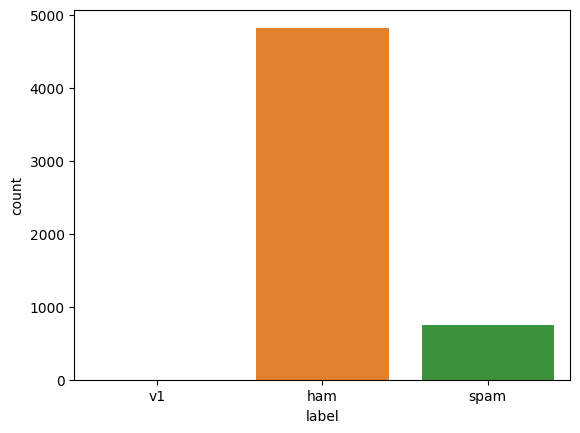

In [15]:
sns.countplot(x='label', data=messages)
plt.show()

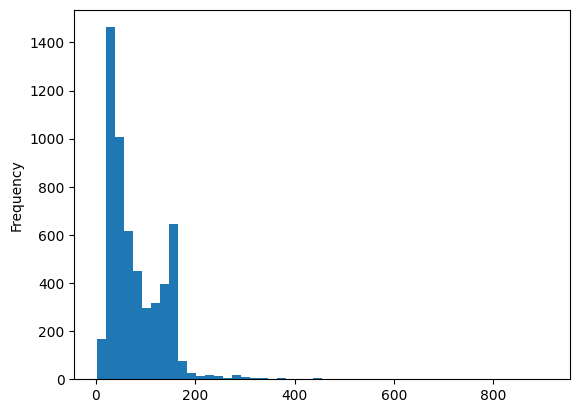

In [16]:
messages['length'].plot(bins=50, kind='hist');

In [17]:
messages.length.describe()

count    5573.000000
mean       80.105150
std        59.695104
min         2.000000
25%        36.000000
50%        61.000000
75%       121.000000
max       910.000000
Name: length, dtype: float64

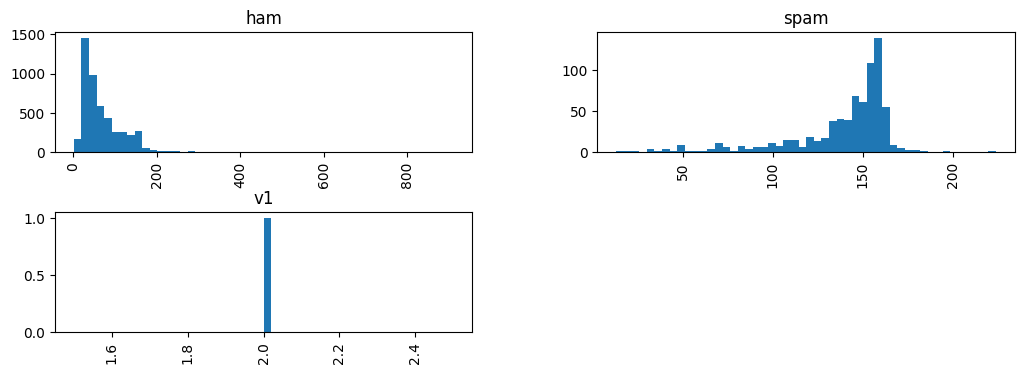

In [18]:
messages.hist(column='length', by='label', bins=50,figsize=(12,4));

## Text Pre-processing

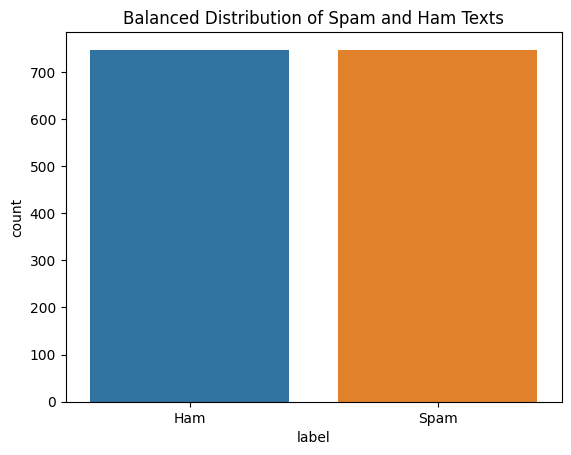

In [19]:
## Balancing classes 
ham_msg = messages[messages['label'] == 'ham']
spam_msg = messages[messages['label'] == 'spam']

# Downsample Ham emails to match the number of Spam emails
ham_msg_balanced = ham_msg.sample(n=len(spam_msg), random_state=42)

# Combine balanced data
messages = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

sns.countplot(x='label', data=messages)
plt.title("Balanced Distribution of Spam and Ham Texts")
plt.xticks(ticks=[0, 1], labels=['Ham', 'Spam'])
plt.show()

In [20]:
mess = 'Sample message! Notice: it has punctuation.'

# Check characters to see if they are in punctuation
nopunc = [char for char in mess if char not in string.punctuation]

# Join the characters again to form the string.
nopunc = ''.join(nopunc)

In [21]:
stopwords.words('english')[0:10] # Show some stop words

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [22]:
nopunc.split()

['Sample', 'message', 'Notice', 'it', 'has', 'punctuation']

In [23]:
# Now just remove any stopwords
clean_mess = [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]

In [24]:
clean_mess

['Sample', 'message', 'Notice', 'punctuation']

In [25]:
def text_process(mess):
    """
    Takes in a string of text, then performs the following:
    1. Remove all punctuation
    2. Remove all stopwords
    3. Returns a list of the cleaned text
    """
    # Check characters to see if they are in punctuation
    nopunc = [char for char in mess if char not in string.punctuation]

    # Join the characters again to form the string.
    nopunc = ''.join(nopunc)
    
    # Now just remove any stopwords
    return [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]

In [26]:
messages.head()

,label,message,v3,v4,v5,length
0,ham,"I am late,so call you tomorrow morning.take ca...",NaN,NaN,NaN,92
1,ham,U r too much close to my heart. If u go away i...,NaN,NaN,NaN,83
2,ham,Wait &lt;#&gt; min..,NaN,NaN,NaN,22
3,ham,Can you call me plz. Your number shows out of ...,NaN,NaN,NaN,139
4,ham,MAYBE IF YOU WOKE UP BEFORE FUCKING 3 THIS WOU...,NaN,NaN,NaN,65


In [27]:
# Check to make sure its working
messages['message'].head(5).apply(text_process)

0    [lateso, call, tomorrow, morningtake, care, sw...
1    [U, r, much, close, heart, u, go, away, shatte...
2                                    [Wait, ltgt, min]
3    [call, plz, number, shows, coveragd, area, urg...
4          [MAYBE, WOKE, FUCKING, 3, WOULDNT, PROBLEM]
Name: message, dtype: object

In [28]:
# Show original dataframe
messages.head()

,label,message,v3,v4,v5,length
0,ham,"I am late,so call you tomorrow morning.take ca...",NaN,NaN,NaN,92
1,ham,U r too much close to my heart. If u go away i...,NaN,NaN,NaN,83
2,ham,Wait &lt;#&gt; min..,NaN,NaN,NaN,22
3,ham,Can you call me plz. Your number shows out of ...,NaN,NaN,NaN,139
4,ham,MAYBE IF YOU WOKE UP BEFORE FUCKING 3 THIS WOU...,NaN,NaN,NaN,65


## Vectorization

In [29]:
# Might take awhile...
bow_transformer = CountVectorizer(analyzer=text_process).fit(messages['message'])

# Print total number of vocab words
logger.info(len(bow_transformer.vocabulary_))

2026-04-15 03:10:03 - INFO - 5482


In [30]:
message4 = messages['message'][3]
logger.info(message4)

2026-04-15 03:10:03 - INFO - Can you call me plz. Your number shows out of coveragd area. I have urgnt call in vasai &amp; have to reach before 4'o clock so call me plz


In [31]:
bow4 = bow_transformer.transform([message4])
logger.info(bow4)
logger.info(bow4.shape)

2026-04-15 03:10:03 - INFO -   (0, 576)	1
  (0, 2657)	1
  (0, 2701)	1
  (0, 2890)	3
  (0, 3022)	1
  (0, 3110)	1
  (0, 4230)	1
  (0, 4386)	2
  (0, 4518)	1
  (0, 4763)	1
  (0, 5155)	1
  (0, 5172)	1
2026-04-15 03:10:03 - INFO - (1, 5482)


In [32]:
# logger.info(bow_transformer.get_feature_names_out()[4073])
# logger.info(bow_transformer.get_feature_names_out()[9570])

In [33]:
messages_bow = bow_transformer.transform(messages['message'])

In [34]:
print('Shape of Sparse Matrix: ', messages_bow.shape)
print('Amount of Non-Zero occurences: ', messages_bow.nnz)

Shape of Sparse Matrix:  (1494, 5482)
Amount of Non-Zero occurences:  17815


In [35]:
sparsity = (100.0 * messages_bow.nnz / (messages_bow.shape[0] * messages_bow.shape[1]))
logger.info('sparsity: {}'.format(round(sparsity)))

2026-04-15 03:10:04 - INFO - sparsity: 0


In [36]:
tfidf_transformer = TfidfTransformer().fit(messages_bow)
tfidf4 = tfidf_transformer.transform(bow4)
logger.info(tfidf4)

2026-04-15 03:10:04 - INFO -   (0, 576)	0.2903561136670107
  (0, 2657)	0.22536972829428517
  (0, 2701)	0.2330194586020592
  (0, 2890)	0.33883006685063327
  (0, 3022)	0.2903561136670107
  (0, 3110)	0.2903561136670107
  (0, 4230)	0.1771214955699968
  (0, 4386)	0.5108527297506068
  (0, 4518)	0.2290030299550454
  (0, 4763)	0.1812466855297405
  (0, 5155)	0.2554263648753034
  (0, 5172)	0.2903561136670107


In [37]:
logger.info(tfidf_transformer.idf_[bow_transformer.vocabulary_['u']])
logger.info(tfidf_transformer.idf_[bow_transformer.vocabulary_['university']])

2026-04-15 03:10:04 - INFO - 3.375407552694095
2026-04-15 03:10:04 - INFO - 7.616734305264841


In [38]:
messages_tfidf = tfidf_transformer.transform(messages_bow)
logger.info(messages_tfidf.shape)

2026-04-15 03:10:04 - INFO - (1494, 5482)


## Training a model

In [39]:
spam_detect_model = MultinomialNB().fit(messages_tfidf, messages['label'])

In [40]:
print('predicted:', spam_detect_model.predict(tfidf4)[0])
print('expected:', messages.label[3])

predicted: ham
expected: ham


## Model Evaluation

In [41]:
all_predictions = spam_detect_model.predict(messages_tfidf)
logger.info(all_predictions)

2026-04-15 03:10:04 - INFO - ['ham' 'ham' 'ham' ... 'spam' 'spam' 'spam']


In [42]:
logger.info(classification_report(messages['label'], all_predictions))

2026-04-15 03:10:04 - INFO -               precision    recall  f1-score   support

         ham       0.98      0.99      0.99       747
        spam       0.99      0.98      0.99       747

    accuracy                           0.99      1494
   macro avg       0.99      0.99      0.99      1494
weighted avg       0.99      0.99      0.99      1494



## Train Test Split

In [43]:
msg_train, msg_test, label_train, label_test = \
train_test_split(messages['message'], messages['label'], test_size=0.2)

print(len(msg_train), len(msg_test), len(msg_train) + len(msg_test))

1195 299 1494


## Creating a Data Pipeline

In [44]:
pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=text_process)),  # strings to token integer counts
    ('tfidf', TfidfTransformer()),  # integer counts to weighted TF-IDF scores
    ('classifier', MultinomialNB()),  # train on TF-IDF vectors w/ Naive Bayes classifier
])

In [45]:
pipeline.fit(msg_train,label_train)

Pipeline(steps=[('bow',
                 CountVectorizer(analyzer=<function text_process at 0x7d63185a1ee0>)),
                ('tfidf', TfidfTransformer()),
                ('classifier', MultinomialNB())])

In [46]:
predictions = pipeline.predict(msg_test)

In [47]:
report = classification_report(predictions,label_test)
logger.info(report)

2026-04-15 03:10:05 - INFO -               precision    recall  f1-score   support

         ham       0.95      0.95      0.95       145
        spam       0.95      0.95      0.95       154

    accuracy                           0.95       299
   macro avg       0.95      0.95      0.95       299
weighted avg       0.95      0.95      0.95       299



In [48]:
end_time: float = time.time()
elapsed_time: float = end_time - start_time
elapsed_minutes: int = int(elapsed_time // 60)
elapsed_seconds: float = elapsed_time % 60

logger.info(f"⏱️ Total execution time: {elapsed_minutes}m {elapsed_seconds:.2f}s")

2026-04-15 03:10:05 - INFO - ⏱️ Total execution time: 0m 10.60s


In [49]:
print("Notebook execution completed successfully.")

Notebook execution completed successfully.


Built with ❤️ using [**Z by HP AI Studio**](https://zdocs.datascience.hp.com/docs/aistudio/overview).